<a href="https://colab.research.google.com/github/letter-b/lab-intro-to-ml/blob/main/lab_intro_to_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB | Intro to Machine Learning

**Load the data**

In this challenge, we will be working with Spaceship Titanic data. The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

In [ ]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**Check the shape of your data**

In [ ]:
#your code here
spaceship.shape

(8693, 14)

**Check for data types**

In [ ]:
#your code here
spaceship.dtypes

,0
PassengerId,object
HomePlanet,object
CryoSleep,object
Cabin,object
Destination,object
Age,float64
VIP,object
RoomService,float64
FoodCourt,float64
ShoppingMall,float64


**Check for missing values**

In [ ]:
#your code here
spaceship.isna().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


There are multiple strategies to handle missing data

- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

For this exercise, because we have such low amount of null values, we will drop rows containing any missing value.

In [ ]:
#your code here
spaceship.dropna(inplace=True)
spaceship.isna().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0


**KNN**

K Nearest Neighbors is a distance based algorithm, and requeries all **input data to be numerical.**

Let's only select numerical columns as our features.

In [ ]:
#your code here
spaceship_num = spaceship.select_dtypes(include=np.number)
spaceship_num.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0


And also lets define our target.

In [14]:
#your code here
target = spaceship["Transported"]
target.head()

,Transported
0,False
1,True
2,False
3,False
4,True


**Train Test Split**

Now that we have split the data into **features** and **target** variables and imported the **train_test_split** function, split X and y into X_train, X_test, y_train, and y_test. 80% of the data should be in the training set and 20% in the test set.

In [15]:
#your code here
X_train, X_test, y_train, y_test = train_test_split(spaceship_num, target, test_size=0.2, random_state=42)

In [18]:
X_train.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
7832,25.0,0.0,1673.0,0.0,642.0,612.0
5842,36.0,0.0,2624.0,1657.0,2799.0,1.0
3928,34.0,0.0,0.0,0.0,0.0,0.0
4091,37.0,0.0,0.0,0.0,0.0,0.0
7679,22.0,0.0,0.0,0.0,0.0,0.0


In [19]:
y_train.head()

,Transported
7832,False
5842,False
3928,True
4091,True
7679,True


**Model Selection**

In this exercise we will be using **KNN** as our predictive model.

You need to choose between **Classificator** or **Regressor**. Take into consideration target variable to decide.

Initialize a KNN instance without setting any hyperparameter.

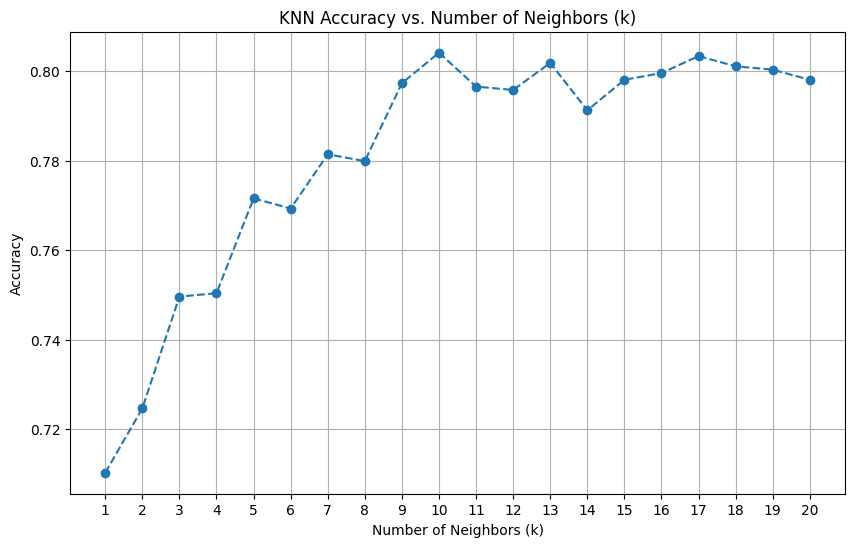

In [32]:
#Trying to find a good "n_neighbors" number.
import matplotlib.pyplot as plt

accuracies = []
k_range = range(1, 21) # Test k from 1 to 20

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(knn.score(X_test, y_test))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--')
plt.title('KNN Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [39]:
#from the cell above, 10 seems to be a good number
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10)

Fit the model to your data.

In [40]:
#your code here
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

The plot above shows the accuracy of the KNN model for different values of `n_neighbors`. You can use this plot to identify the `k` value that yields the highest accuracy or a good balance between bias and variance. Once you have chosen an optimal `n_neighbors` value, you can update the `knn` model initialization accordingly.

Evaluate your model.

In [41]:
#your code here
knn.score(X_test, y_test)

0.8040847201210287

**Congratulations, you have just developed your first Machine Learning model!**